# 23.6) DBSCAN X Hierárquico X K-Means


criação dos dados em uma distribuição específica 


In [16]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

In [17]:
from sklearn import datasets



In [18]:
# criaremos 1500 registros
# como 2 variáveis no X_random e uma coluna de grupo no y_random
X_random, y_random = datasets.make_moons(n_samples=1500)

In [19]:
# analisar os grupos
np.unique(y_random)


array([0, 1])

In [20]:
np.unique(y_random, return_counts=True)

(array([0, 1]), array([750, 750]))

# verificar a distribuição, interessante, de 2 espirais

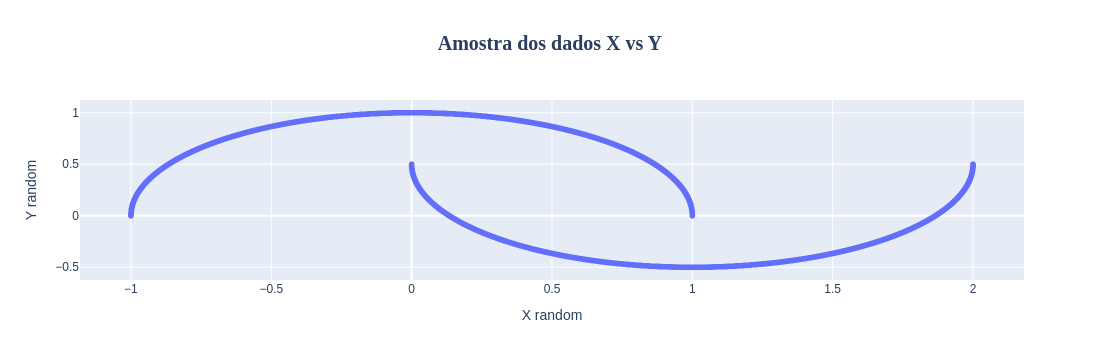

In [21]:
grafico = px.scatter(x = X_random[:,0], y = X_random[:,1], title='<b>Amostra dos dados X vs Y </b>')

grafico.update_layout(
    xaxis_title_text='X random',
    yaxis_title_text='Y random',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

grafico.show()
grafico.write_html("Figuras/19-5_grafico1.html")

In [22]:
# para os dados ficarem mais dispersos, colocamos valores no noise (ruídos)
X_random, y_random = datasets.make_moons(n_samples=1500, noise = 0.09)
np.unique(y_random, return_counts=True)

(array([0, 1]), array([750, 750]))

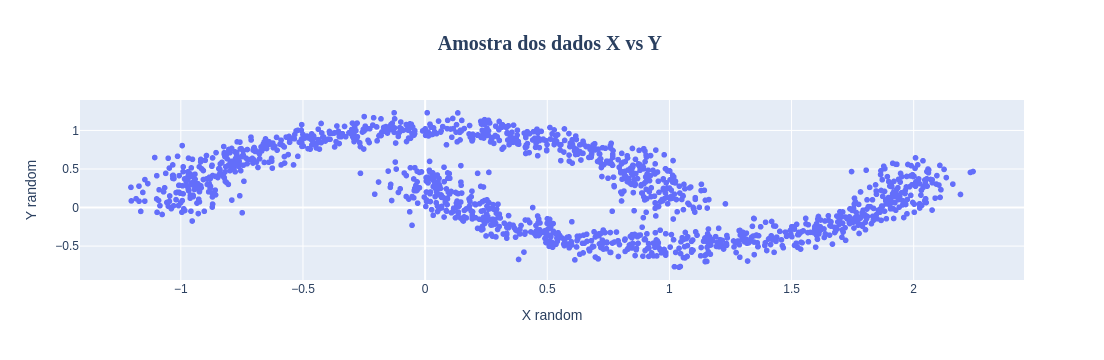

In [23]:
grafico = px.scatter(x = X_random[:,0], y = X_random[:,1], title='<b>Amostra dos dados X vs Y </b>')

grafico.update_layout(
    xaxis_title_text='X random',
    yaxis_title_text='Y random',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

grafico.show()
grafico.write_html("Figuras/19-5_grafico2.html")

# claramente temos 2 grupos

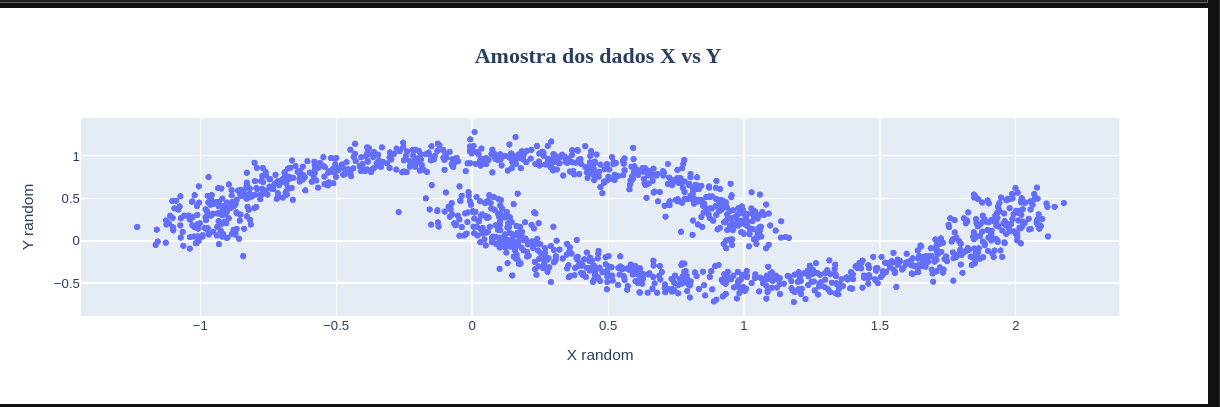

vamos aplicar os algoritimos para agrupar os dados com: DBSCAN X Hierárquico X K-Means, e verificar quais fizeram de forma correta. 

# KMEANS

{0, 1}


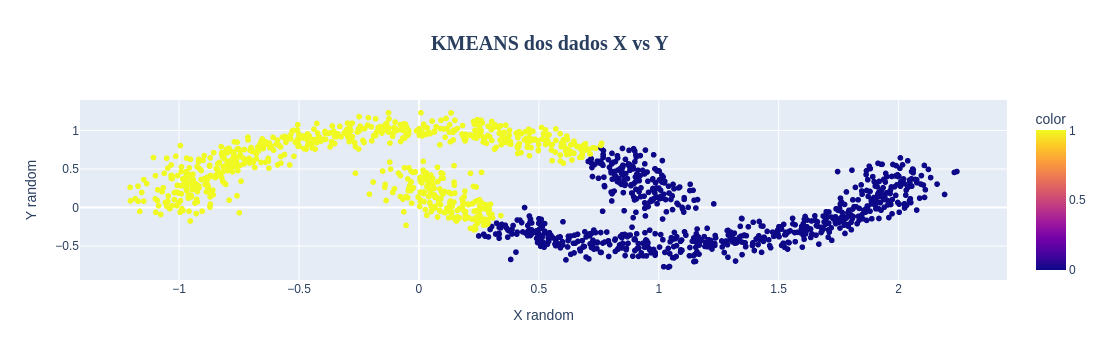

In [24]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2) # 2 clusters
rotulos = kmeans.fit_predict(X_random) # previsão e modelar
print(set(rotulos))
grafico = px.scatter(x = X_random[:,0], y = X_random[:, 1], color = rotulos, title='<b>KMEANS dos dados X vs Y </b>')

grafico.update_layout(
    xaxis_title_text='X random',
    yaxis_title_text='Y random',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

grafico.show()
grafico.write_html("Figuras/19-5_grafico3.html")

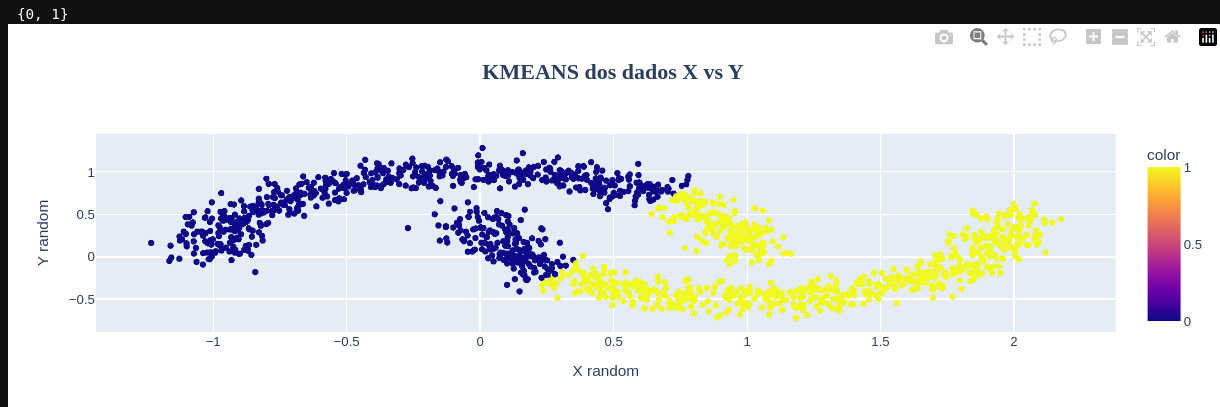

kmeans não deu certo nete exemplo, pois utiliza o cálculo das distâncias. 

não passado os parâmetros


In [25]:
from sklearn.cluster import AgglomerativeClustering

{0, 1}


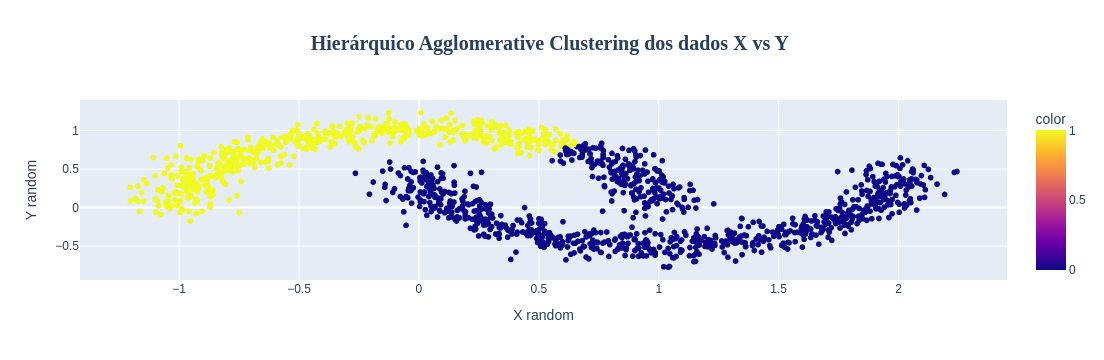

In [26]:
#hc = AgglomerativeClustering(n_clusters=2, affinity='euclidean', linkage='ward')
hc = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
rotulos = hc.fit_predict(X_random)
print(set(rotulos))
grafico = px.scatter(x = X_random[:,0], y = X_random[:, 1], color = rotulos, title='<b>Hierárquico Agglomerative Clustering dos dados X vs Y </b>')

grafico.update_layout(
    xaxis_title_text='X random',
    yaxis_title_text='Y random',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

grafico.show()
grafico.write_html("Figuras/19-5_grafico4.html")



Resultado melhor, porém misturou o elemento da classe 1. Já o da classe 0 foi toda detectada. 



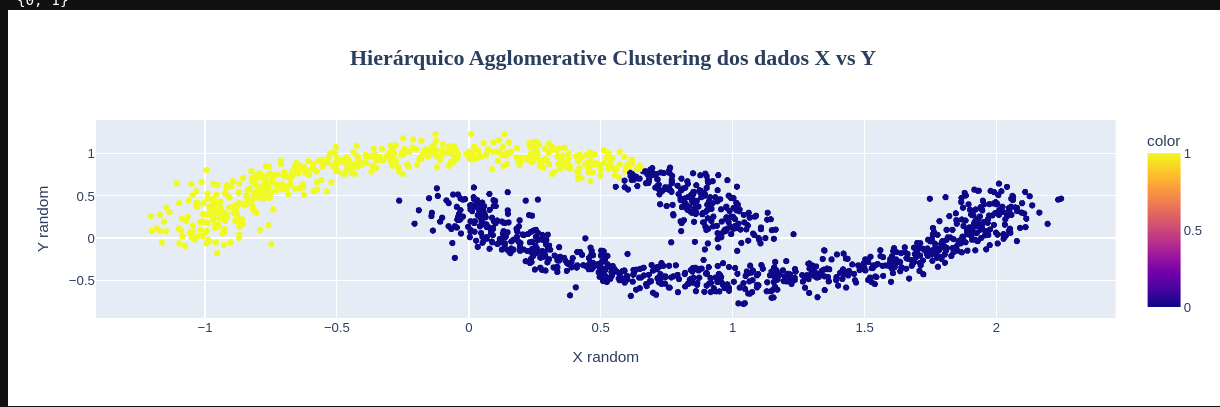



In [27]:
from sklearn.cluster import DBSCAN

{0}


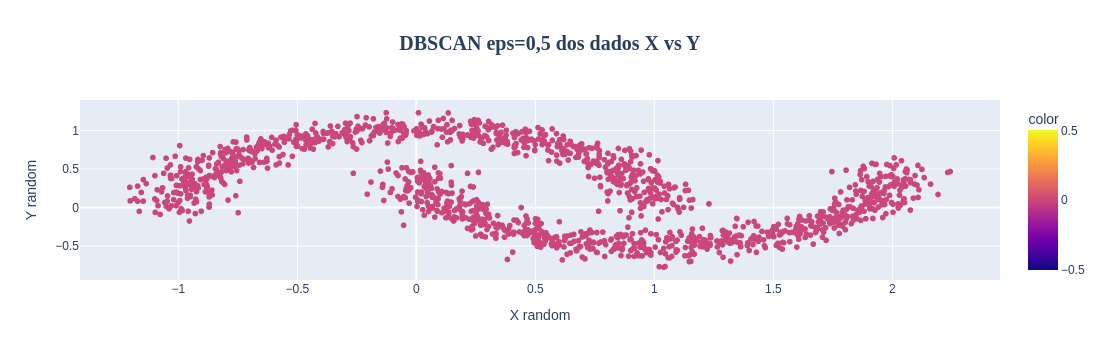

In [29]:
dbscan = DBSCAN(eps=0.5) # padrão do raio é de 0,5 eps
rotulos = dbscan.fit_predict(X_random)
print(set(rotulos))
grafico = px.scatter(x = X_random[:,0], y = X_random[:, 1], color = rotulos, title='<b>DBSCAN eps=0,5 dos dados X vs Y </b>')

grafico.update_layout(
    xaxis_title_text='X random',
    yaxis_title_text='Y random',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

grafico.show()
grafico.write_html("Figuras/19-5_grafico5.html")

In [30]:
# ruim, ficou apenas um grupo, de 1 grupo => 0

{0, 1, -1}


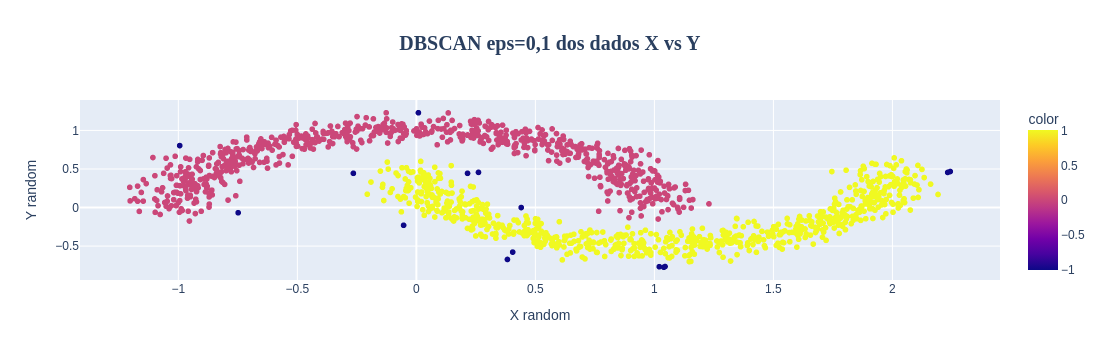

In [31]:
dbscan = DBSCAN(eps=0.1) # raio é de 0,1 eps
rotulos = dbscan.fit_predict(X_random)
print(set(rotulos))
grafico = px.scatter(x = X_random[:,0], y = X_random[:, 1], color = rotulos, title='<b>DBSCAN eps=0,1 dos dados X vs Y </b>')

grafico.update_layout(
    xaxis_title_text='X random',
    yaxis_title_text='Y random',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

grafico.show()
grafico.write_html("Figuras/19-5_grafico6.html")

In [35]:
# mais coerente, com 3 grupos, sendo 2 corretos, grupos perfeitos, e o -1 ruídos

# detalhe é que foi escolhido um raio pequeno, de 0,1
# parâmetro dos raios, 

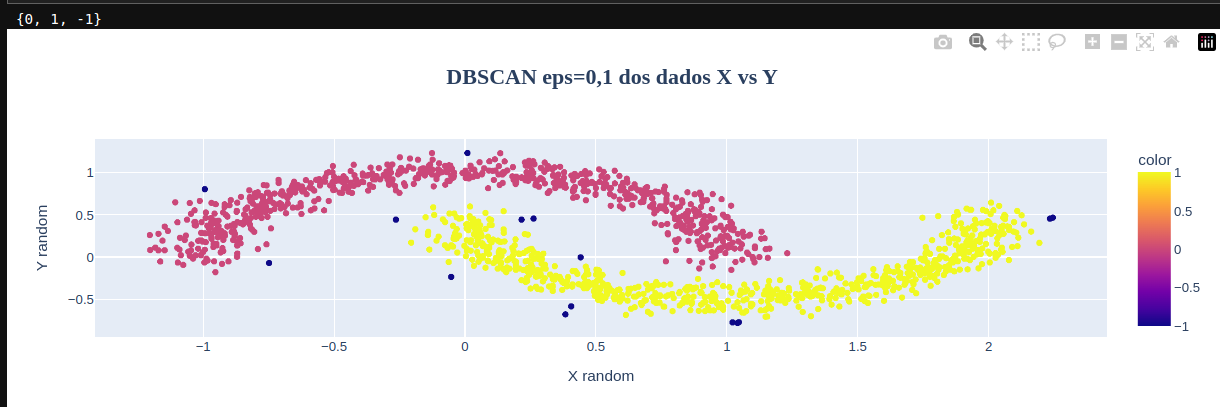

# para o agrupamento do cartão de crédito os dois primeiros algoritimos são mais adequados => KMEANS e Hierárquico

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, -1}


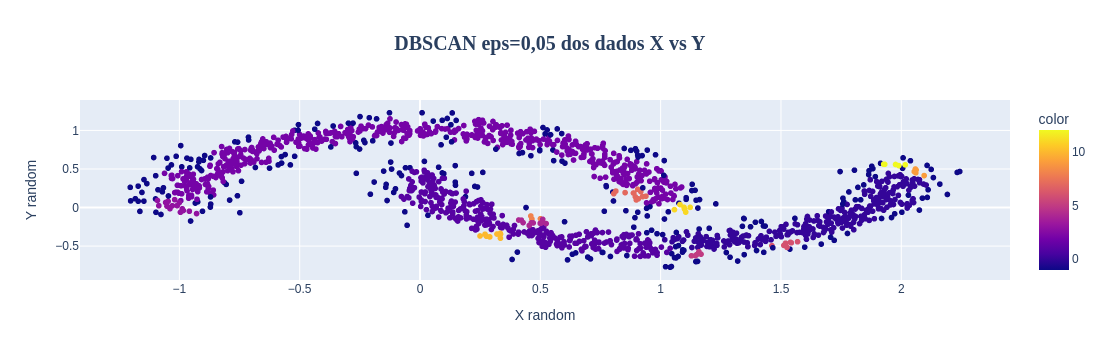

In [36]:
dbscan = DBSCAN(eps=0.05) # raio é de 0,05 eps
rotulos = dbscan.fit_predict(X_random)
print(set(rotulos))
grafico = px.scatter(x = X_random[:,0], y = X_random[:, 1], color = rotulos, title='<b>DBSCAN eps=0,05 dos dados X vs Y </b>')

grafico.update_layout(
    xaxis_title_text='X random',
    yaxis_title_text='Y random',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

grafico.show()
grafico.write_html("Figuras/19-5_grafico7.html")

In [37]:
# ficou melhor o eps com 0,1